In [1]:
import pandas as pd

As a default, I'll load the version where some rows are null in the SMAs. 

In [4]:
# Load the full dataset. All other dataframes will be iterations from this one.
df_daily_five_yr = pd.read_csv('daily_data/daily_cleaned_2a.csv')

# Timestamp conversion, feel like I am always doing this yet it is never done.
df_daily_five_yr['timestamp'] = pd.to_datetime(df_daily_five_yr['timestamp'])

df_daily_five_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change
0,2021-05-24,A,133.51,134.41,132.5300,133.34,1.325305e+06,133.6936,18683.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,NaN,-0.082496
1,2021-05-25,A,133.41,134.80,133.0100,133.23,1.905708e+06,133.6992,26967.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,-0.082496,0.045035
2,2021-05-26,A,136.30,138.00,133.2505,133.29,2.530998e+06,134.5671,31259.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.045035,3.188536
3,2021-05-27,A,133.32,138.14,133.1600,137.54,3.720923e+06,137.2590,37177.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,3.188536,0.428966
4,2021-05-28,A,138.60,139.21,138.0001,138.13,1.289049e+06,138.4188,20108.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,NaN,NaN,NaN,NaN,0.428966,-0.673279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.34,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427
3493828,2026-05-18,ZYME,23.93,24.70,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800
3493829,2026-05-19,ZYME,24.19,24.55,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279
3493830,2026-05-20,ZYME,24.40,25.20,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957


In [3]:
df_daily_two_yr = df_daily_five_yr[df_daily_five_yr['timestamp'] >= '2024-05-21']
df_daily_one_yr = df_daily_five_yr[df_daily_five_yr['timestamp'] >= '2025-05-21']

# Running commands from files

This command calculates a new column displaying, for any dataframe, the close price as a percentage of its value in the first day of the dataset. This must be done separately to each dataframe, and without using a loop the codeblock would become bloated.

Eventually, my intention is to scale this up so that many alternate datasets can be created quickly without calculating or filtering logic having to be repeated over and over, and so that multiple nearly redundant datasets won't have to be stored as slightly different files.

In [5]:
dfs = df_daily_five_yr, df_daily_two_yr, df_daily_one_yr

for df in dfs:
    # CALLING FROM FILE
    with open("daily_data/COMMAND calculate pct of first day.txt", "r") as file:
        code = file.read()
        exec(code)

<string>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Let's see if this worked on df_daily_two_yr, which was created from df_daily_five_yr before this filter was applied.

In [6]:
df_daily_two_yr

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,name,market_cap,exchange,country,SMA10,SMA20,SMA50,SMA100,pct_change_from_prev,next_close_pct_change,close_pct_of_day1
753,2024-05-21,A,154.35,154.6500,152.3400,153.67,9.971140e+05,153.7217,22144.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,150.767,144.6720,143.8422,139.17820,-0.627263,-0.520596,100.000000
754,2024-05-22,A,153.58,154.4900,152.6400,152.87,1.231261e+06,153.3977,25802.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,151.774,145.4410,143.9428,139.30920,-0.520596,-1.517629,99.479404
755,2024-05-23,A,152.47,152.4700,150.1100,150.55,1.005202e+06,151.0730,23828.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,152.315,146.1500,143.9974,139.42440,-1.517629,0.073065,97.969675
756,2024-05-24,A,150.81,151.4555,149.5600,150.66,7.843330e+05,150.3161,18460.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,152.405,146.7960,144.1064,139.54350,0.073065,-1.626178,98.041257
757,2024-05-28,A,150.82,151.1900,147.7000,148.21,1.366918e+06,148.5080,24011.0,Agilent Technologies Inc.,3.215449e+10,XNYS,us,152.450,147.2270,144.1210,139.71400,-1.626178,-1.841981,96.446932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493827,2026-05-15,ZYME,24.50,25.3400,23.6346,23.93,6.407959e+05,23.8908,11366.0,Zymeworks Inc.,1.827577e+09,XNAS,us,25.195,26.5305,25.6757,24.81475,-0.125209,2.089427,268.574635
3493828,2026-05-18,ZYME,23.93,24.7000,23.8800,24.43,7.502414e+05,24.3372,14709.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.960,26.3595,25.6827,24.78285,2.089427,-0.122800,274.186308
3493829,2026-05-19,ZYME,24.19,24.5500,23.8700,24.40,6.153201e+05,24.3494,12503.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.732,26.1660,25.6857,24.75895,-0.122800,1.803279,273.849607
3493830,2026-05-20,ZYME,24.40,25.2000,24.2650,24.84,5.426638e+05,24.8734,13051.0,Zymeworks Inc.,1.827577e+09,XNAS,us,24.455,25.9815,25.6733,24.73875,1.803279,1.086957,278.787879


# 1. Fetch both daily and hourly stock market data using a suitable API. Visualize the data in several types of plots.

Refer to notebook 1A - Cleaning.

# 2. Plot long-term stock data over multiple years. Create an interactive graph that allows the user to view different time ranges.

This will be on the Streamlit app when I create it.

# 3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.

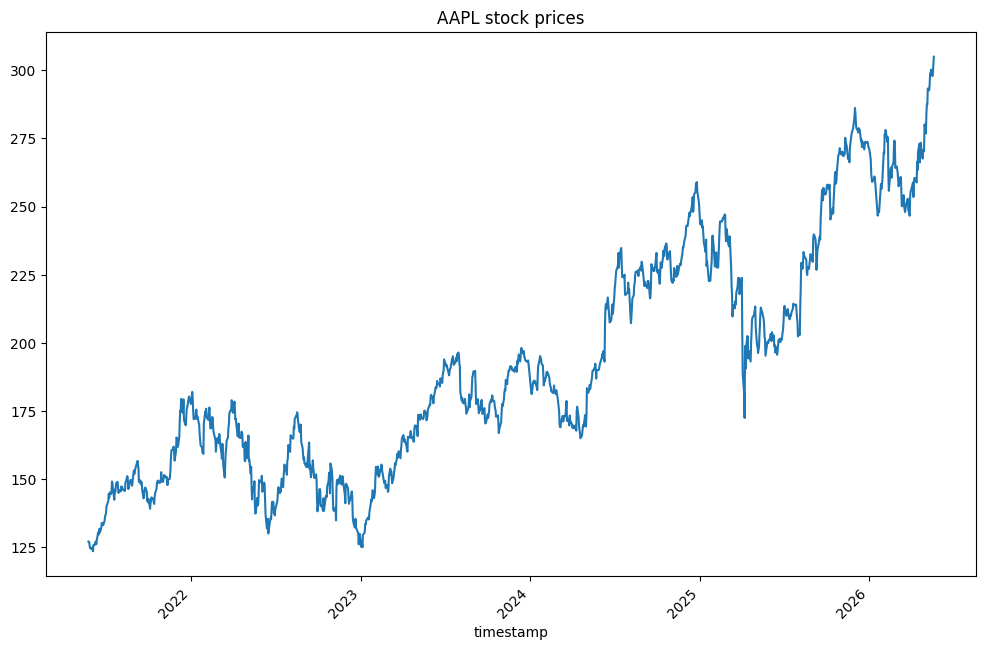

In [210]:
import matplotlib.pyplot as plt

aapl_df = df_daily_five_yr[df_daily_five_yr['ticker'] == 'AAPL']

plt.figure(figsize=(12, 8))
aapl_df.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AAPL stock prices')
plt.show()

# 4. Add moving averages to the stock charts.

I added SMA10, SMA20, SMA50, and SMA100. However SMA10 was excluded from the visualization as it cluttered things up and made the original line too hard to see.

In this visualization, I used the dataset which leaves the nulls from the SMAs (days for which there was insufficient data to calculate them). You can see each SMA as it begins, and see how it is still taking into account the days before it.

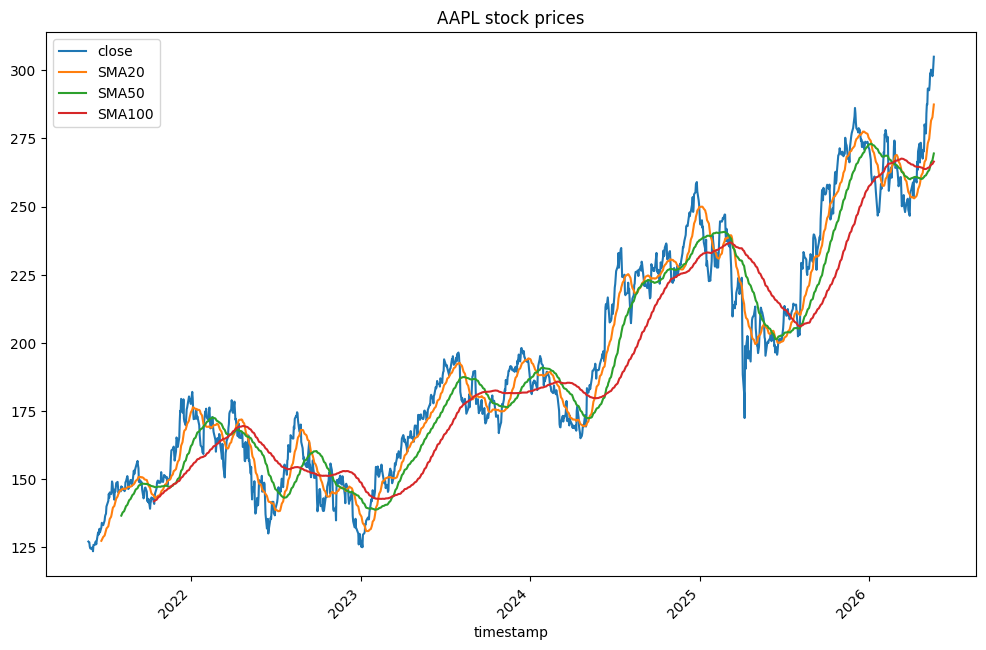

In [211]:
import matplotlib.pyplot as plt

aapl_df = df_daily_five_yr[df_daily_five_yr['ticker'] == 'AAPL']

features_to_plot = ['close', 'SMA20', 'SMA50', 'SMA100']

plt.figure(figsize=(12, 8))

for feature in features_to_plot:
    aapl_df.set_index('timestamp')[feature].plot()
    plt.xticks(rotation=45)
    # This title will have to be changed if SMA and next_close stats result in rows being dropped
    plt.title('AAPL stock prices')
    plt.legend()
plt.show()

# 5. Create a table for five stocks. Use default examples such as FAANG stocks plus NVIDIA, but allow the user to change them.

For each stock, calculate the historical probability that the next day is positive if the
current day changes by: +2%, +3%, +4%, +5%, and +6%.

Example: if Apple rises 5% today, what is the historical probability that the next day closes positive?

Use the last 2 years of historical data.


Here I will use seven standard tech stocks. In the eventual streamlit page, I will introduce the interactivity.

I was asked to verify my calculations, so I did a small version here. I am confident that my calculations are correct.

In [174]:
aapl_two_yr = df_daily_two_yr[df_daily_two_yr['ticker'] == 'AAPL']

increase_2pct = (aapl_two_yr['pct_change_from_prev'] >= 2).sum()
increase_2pct_and_next_pos = ((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] >= 0)).sum()
increase_2pct_and_next_neg = ((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] < 0)).sum()


print(f"Days with 2% increase over previous day:\n\t{increase_2pct}")
print(f"Days with 2% increase over previous day AND next day positive:\n\t{increase_2pct_and_next_pos}")
print(f"Days with 2% increase over previous day AND next day negative:\n\t{increase_2pct_and_next_neg}")
print(f"Percentage of 2% increase days where next day was positive:\n\t" f"{(increase_2pct_and_next_pos / increase_2pct) * 100:.3f}%")

Days with 2% increase over previous day:
	43
Days with 2% increase over previous day AND next day positive:
	29
Days with 2% increase over previous day AND next day negative:
	14
Percentage of 2% increase days where next day was positive:
	67.442%


For visual verification, I'll run boolean indexing on rows satisying conditions.

In [180]:
(aapl_two_yr['pct_change_from_prev'] >= 2).sum()

np.int64(43)

In [181]:
((aapl_two_yr['pct_change_from_prev'] >= 2) & (aapl_two_yr['next_close_pct_change'] >= 0)).sum()

np.int64(29)

In [198]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = df_daily_two_yr

print("Span: 2 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a positive change the day after a {threshold}% increase:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% increase <<<<")

    print(f"-------------------------------------------------------------------------------------------")

Span: 2 years

AAPL:	Probability of a positive change the day after a 2% increase:	67.442	(29 / 43)
AAPL:	Probability of a positive change the day after a 3% increase:	66.667	(12 / 18)
AAPL:	Probability of a positive change the day after a 4% increase:	50.000	(4 / 8)
AAPL:	Probability of a positive change the day after a 5% increase:	75.000	(3 / 4)
AAPL:	Probability of a positive change the day after a 6% increase:	66.667	(2 / 3)
AAPL:	Probability of a positive change the day after a 10% increase:	0.000	(0 / 1)
AAPL:	>>>> No days with a 20% increase <<<<
-------------------------------------------------------------------------------------------
NVDA:	Probability of a positive change the day after a 2% increase:	53.846	(63 / 117)
NVDA:	Probability of a positive change the day after a 3% increase:	50.667	(38 / 75)
NVDA:	Probability of a positive change the day after a 4% increase:	52.500	(21 / 40)
NVDA:	Probability of a positive change the day after a 5% increase:	57.895	(11 / 19)
NVDA:	

# 6. Repeat the same analysis for negative daily moves, such as: -2%, -3%, -4%, and -5%.

In [199]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

master_df = df_daily_two_yr

print("Span: 2 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change the day after a {threshold}% decrease:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")

        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-------------------------------------------------------------------------------------------")

Span: 2 years

AMZN:	Probability of a negative change the day after a -1% decrease:	45.312	(58 / 128)
AMZN:	Probability of a negative change the day after a -2% decrease:	40.741	(22 / 54)
AMZN:	Probability of a negative change the day after a -3% decrease:	44.000	(11 / 25)
AMZN:	Probability of a negative change the day after a -4% decrease:	50.000	(7 / 14)
AMZN:	Probability of a negative change the day after a -5% decrease:	80.000	(4 / 5)
AMZN:	Probability of a negative change the day after a -6% decrease:	100.000	(3 / 3)
AMZN:	>>>> No days with a -10% decrease <<<<
AMZN:	>>>> No days with a -15% decrease <<<<
AMZN:	>>>> No days with a -20% decrease <<<<
-------------------------------------------------------------------------------------------
AAPL:	Probability of a negative change the day after a -1% decrease:	44.681	(42 / 94)
AAPL:	Probability of a negative change the day after a -2% decrease:	40.909	(18 / 44)
AAPL:	Probability of a negative change the day after a -3% decrease:	40.0

# 7a. Positive moves over 5 years

In [200]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AAPL', 'NVDA', 'NFLX', 'AMZN', 'GOOGL', 'META', 'MSFT']

thresholds = 2, 3, 4, 5, 6, 10, 20

master_df = df_daily_five_yr

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] >= threshold
        next_change_condition = ticker_df['next_close_pct_change'] >= 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a positive change the day after a {threshold}% increase:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% increase <<<<")

    print(f"-------------------------------------------------------------------------------------------")

Span: 5 years

AAPL:	Probability of a positive change the day after a 2% increase:	53.226	(66 / 124)
AAPL:	Probability of a positive change the day after a 3% increase:	50.000	(23 / 46)
AAPL:	Probability of a positive change the day after a 4% increase:	42.105	(8 / 19)
AAPL:	Probability of a positive change the day after a 5% increase:	62.500	(5 / 8)
AAPL:	Probability of a positive change the day after a 6% increase:	66.667	(4 / 6)
AAPL:	Probability of a positive change the day after a 10% increase:	0.000	(0 / 1)
AAPL:	>>>> No days with a 20% increase <<<<
-------------------------------------------------------------------------------------------
NVDA:	Probability of a positive change the day after a 2% increase:	54.921	(173 / 315)
NVDA:	Probability of a positive change the day after a 3% increase:	54.187	(110 / 203)
NVDA:	Probability of a positive change the day after a 4% increase:	53.175	(67 / 126)
NVDA:	Probability of a positive change the day after a 5% increase:	56.944	(41 / 72)


# 7b. Negative moves over 5 years

In [201]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

master_df = df_daily_five_yr

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change the day after a {threshold}% decrease:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-------------------------------------------------------------------------------------------")

Span: 5 years

AMZN:	Probability of a negative change the day after a -1% decrease:	47.661	(163 / 342)
AMZN:	Probability of a negative change the day after a -2% decrease:	44.025	(70 / 159)
AMZN:	Probability of a negative change the day after a -3% decrease:	44.872	(35 / 78)
AMZN:	Probability of a negative change the day after a -4% decrease:	53.488	(23 / 43)
AMZN:	Probability of a negative change the day after a -5% decrease:	52.174	(12 / 23)
AMZN:	Probability of a negative change the day after a -6% decrease:	54.545	(6 / 11)
AMZN:	Probability of a negative change the day after a -10% decrease:	0.000	(0 / 1)
AMZN:	>>>> No days with a -15% decrease <<<<
AMZN:	>>>> No days with a -20% decrease <<<<
-------------------------------------------------------------------------------------------
AAPL:	Probability of a negative change the day after a -1% decrease:	51.181	(130 / 254)
AAPL:	Probability of a negative change the day after a -2% decrease:	43.860	(50 / 114)
AAPL:	Probability of a neg

# 8. Create a comparison table for the five selected stocks.
Include a simple correlation / collinearity analysis between them.

# 9. Plot a comparison chart for two to five stocks using daily data for one year.


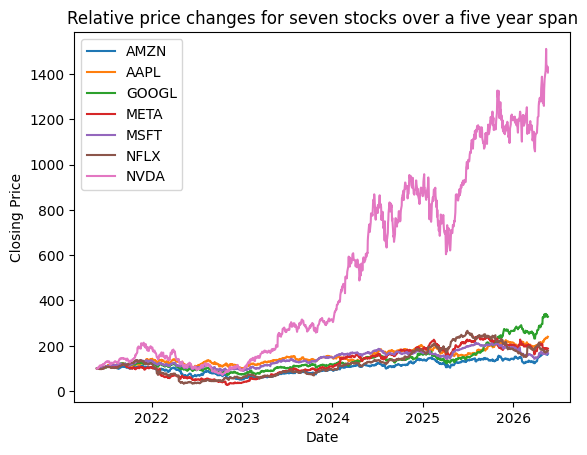

In [213]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

master_df = df_daily_five_yr
#master_df = df_daily_five_yr
#master_df = df_daily_five_yr


for stock in tech_stocks:
    stock_df = master_df[master_df['ticker'] == stock]
    plt.plot(stock_df['timestamp'], stock_df['close_pct_of_day1'], label=stock)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.title('Relative price changes for seven stocks over a five year span')
    plt.legend()

plt.show()

Did the above completely myself. Below with some assistance for date formatting and figure size improvement.

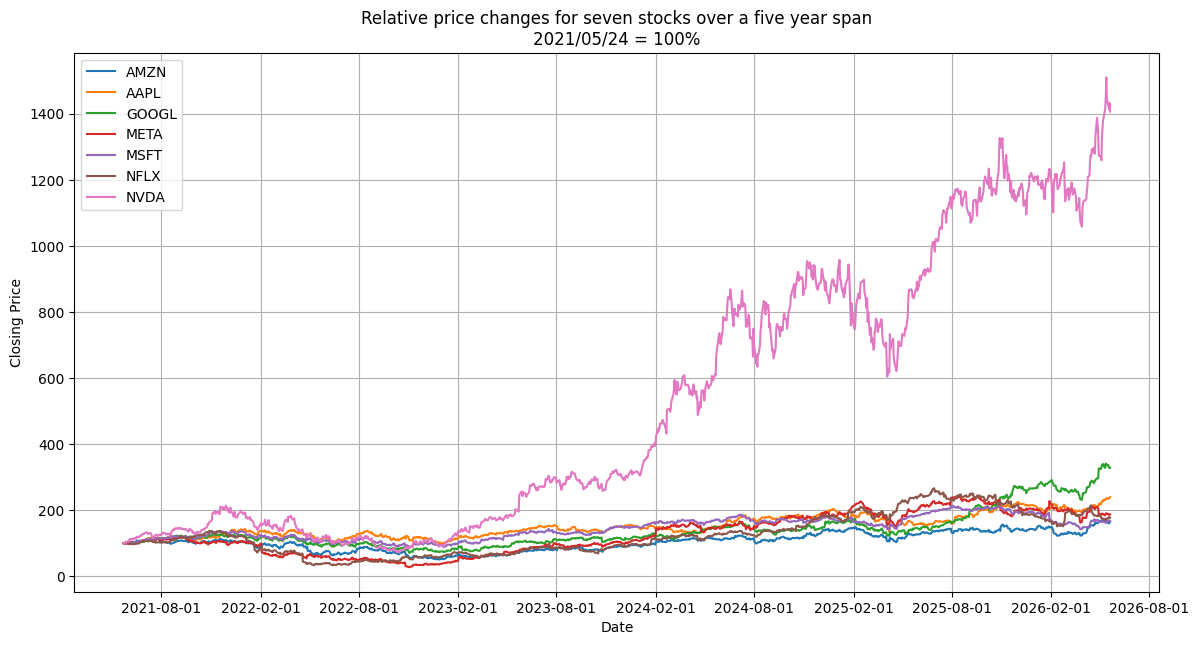

In [217]:
# Five year span
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

master_df = df_daily_five_yr

plt.figure(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = master_df[master_df['ticker'] == stock]
    plt.plot(stock_df['timestamp'], stock_df['close_pct_of_day1'], label=stock)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.title(
    f'Relative price changes for seven stocks over a five year span\n'
    f'{(master_df['timestamp'].min()):%Y/%m/%d} = 100%')
    plt.legend()

# Fewer x-axis ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Optional rotation
plt.xticks(rotation=0)
plt.grid()
plt.show()

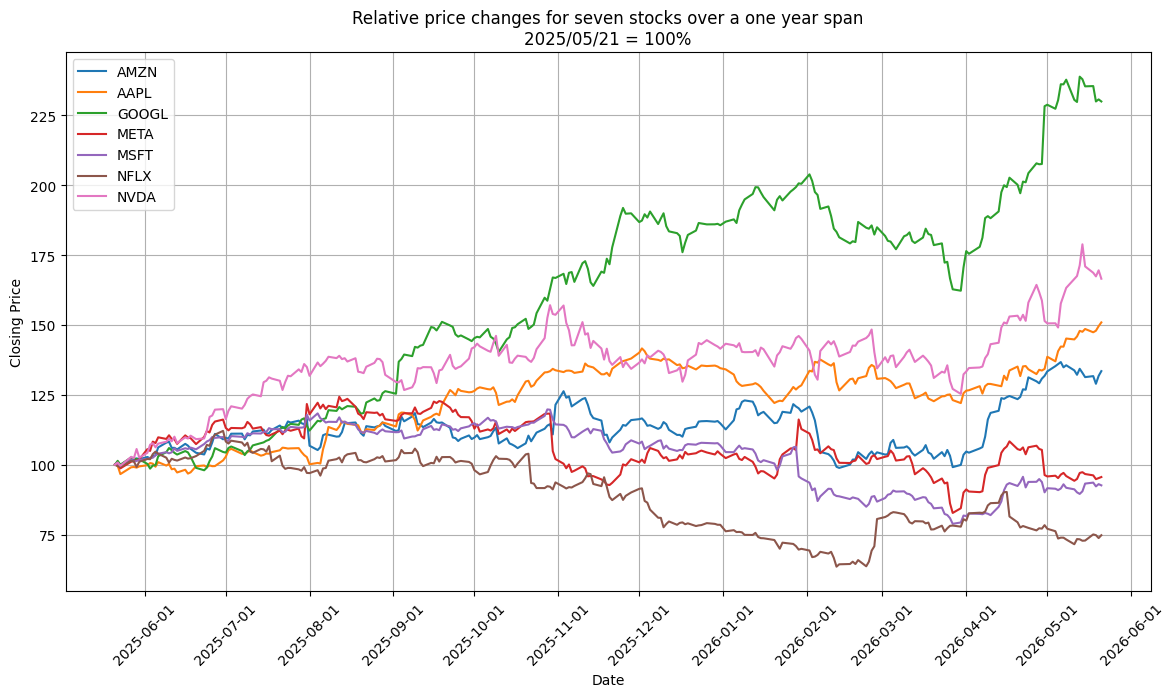

In [218]:
# One year span
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

tech_stocks = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

#master_df = df_daily_five_yr
#master_df = df_daily_two_yr
master_df = df_daily_one_yr

earliest_date = master_df['timestamp'].min()

plt.figure(figsize=(14, 7))

for stock in tech_stocks:
    stock_df = master_df[master_df['ticker'] == stock]
    plt.plot(stock_df['timestamp'], stock_df['close_pct_of_day1'], label=stock)
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.title(
    f'Relative price changes for seven stocks over a one year span\n'
    f'{earliest_date:%Y/%m/%d} = 100%')
    plt.legend()

# Fewer x-axis ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Optional rotation
plt.xticks(rotation=45)
plt.grid()
plt.show()

# 10. Create another table for the same five stocks showing the probability that the next day is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days

In [202]:
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

streak_lengths = 2, 3, 4, 5, 6

master_df = df_daily_five_yr

print("Span: 5 years\n")

for streak in streak_lengths
    ticker_df = master_df[master_df['ticker'] == ticker]

In [ ]:
#ticker_list = df_daily_two_years['ticker'].unique().tolist()
ticker_list = ['AMZN', 'AAPL', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA']

thresholds = -1, -2, -3, -4, -5, -6, -10, -15, -20

master_df = df_daily_five_yr

print("Span: 5 years\n")

for ticker in ticker_list:
    ticker_df = master_df[master_df['ticker'] == ticker]

    for threshold in thresholds:
        prev_change_condition = ticker_df['pct_change_from_prev'] <= threshold
        next_change_condition = ticker_df['next_close_pct_change'] < 0

        full_condition = prev_change_condition & next_change_condition

        matching_days = full_condition.sum()
        total_prev_days = prev_change_condition.sum()

        if total_prev_days > 0:
            full_condition_pct = (matching_days / total_prev_days) * 100

            print(f"{ticker}:\tProbability of a negative change the day after a {threshold}% decrease:\t{full_condition_pct:.3f}\t({matching_days} / {total_prev_days})")
        else:
            print(f"{ticker}:\t>>>> No days with a {threshold}% decrease <<<<")
    print(f"-------------------------------------------------------------------------------------------")

# 11. Repeat the same analysis for consecutive negative days.

# 12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked by daily percentage change.

I will make two versions - one for the most recent day in the dataset over the previous, and another for the highest relative to the beginning of the dataset.

## 12a - Strongest trends in the most recent day

In [56]:
recent_day_df = df_daily_five_yr[df_daily_five_yr['timestamp'] == df_daily_five_yr['timestamp'].max()]
recent_day_df = recent_day_df[['timestamp', 'ticker', 'name', 'market_cap', 'close', 'pct_change_from_prev', 'close_pct_of_day1']]
recent_day_df.nlargest(10, 'pct_change_from_prev')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
755421,2026-05-21,CODX,"Co-Diagnostics, Inc. Common Stock",8.609891e+06,3.710,55.230126,1.540058
1172081,2026-05-21,FCEL,FuelCell Energy Inc NEW (DE),1.071212e+09,26.380,30.464886,10.345098
1403001,2026-05-21,GOVX,"GeoVax Labs, Inc. New",7.745370e+06,2.750,23.318386,0.142672
2374371,2026-05-21,OTLK,"Outlook Therapeutics, Inc. Common Stock",3.299567e+07,0.333,21.978022,0.690871
180631,2026-05-21,AMPG,AMPLITECH GROUP INC. COM,1.122509e+08,5.290,19.413093,132.581454
798091,2026-05-21,CRBP,"Corbus Pharmaceuticals Holdings, Inc.",1.802754e+08,11.510,18.293936,22.702170
1517206,2026-05-21,HOV,"Hovnanian Enterprises, Inc. Class A",5.820024e+08,115.460,17.804306,92.051343
1070426,2026-05-21,ENPH,"Enphase Energy, Inc.",7.005075e+09,62.340,17.290687,44.253567
662551,2026-05-21,CHGG,"CHEGG, INC.",1.365898e+08,1.430,17.213115,1.932694
3276716,2026-05-21,VERI,"Veritone, Inc. Common Stock",1.821996e+08,2.280,16.326531,12.324324


## 12b - Strongest trends since the beginning of the dataset

In [57]:
recent_day_df.nlargest(10, 'close_pct_of_day1')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
73956,2026-05-21,AEHR,Aehr Test Systems,2.589861e+09,91.30,10.881710,4266.355140
707731,2026-05-21,CLS,"Celestica, Inc.",3.983588e+10,354.77,2.392634,4101.387283
2974261,2026-05-21,STRL,"Sterling Infrastructure, Inc. Common Stock",2.307584e+10,733.77,-2.424202,3342.915718
2532501,2026-05-21,POWL,Powell Industries Inc,9.874798e+09,270.75,-0.110681,2322.698534
1214751,2026-05-21,FIX,"Comfort Systems USA, Inc.",6.461440e+10,1835.33,-0.009807,2272.010399
5019,2026-05-21,AAOI,"Applied Optoelectronics, Inc.",1.326092e+10,176.81,6.988987,2252.356688
1910021,2026-05-21,LQDA,Liquidia Corporation Common Stock,5.493089e+09,61.97,0.323782,1992.604502
415316,2026-05-21,BELFB,Bel Fuse Inc,3.623235e+09,260.40,2.217861,1548.156956
1640196,2026-05-21,INOD,Innodata Inc.,3.092789e+09,98.53,4.033365,1511.196319
2063131,2026-05-21,MOD,Modine Manufacturing Co,1.356932e+10,250.11,-2.805736,1494.086022


I've never heard of AEHR. 4200% increase since May 2021?

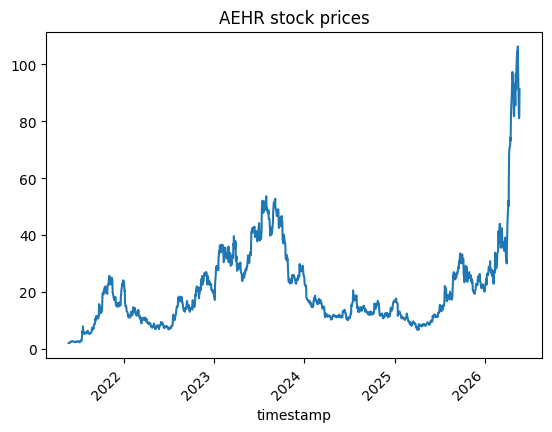

In [59]:
import matplotlib.pyplot as plt

aehr_df = df_daily_five_yr[df_daily_five_yr['ticker'] == 'AEHR']

aehr_df.set_index('timestamp')['close'].plot()
plt.xticks(rotation=45)
# This title will have to be changed if SMA and next_close stats result in rows being dropped
plt.title('AEHR stock prices')
plt.show()

# 13. Repeat the screening, but only include stocks with a market capitalization of $5 billion


In [62]:
market_cap_lim = recent_day_df[recent_day_df['market_cap'] >= 5000000000]
market_cap_lim.nlargest(10, 'pct_change_from_prev')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
1070426,2026-05-21,ENPH,"Enphase Energy, Inc.",7.005075e+09,62.34,17.290687,44.253567
357586,2026-05-21,AXTI,AXT Inc,6.843919e+09,121.02,15.686837,1200.595238
2688121,2026-05-21,RL,Ralph Lauren Corporation,1.993101e+10,374.90,13.868303,313.435331
2924061,2026-05-21,SPOT,Spotify Technology S.A.,8.909928e+10,489.93,13.064248,209.318124
1578701,2026-05-21,IBM,International Business Machines Corporation,2.114742e+11,252.97,12.431111,182.840449
1072936,2026-05-21,ENS,"EnerSys, Inc.",7.906831e+09,238.91,11.348807,255.819681
1869861,2026-05-21,LITE,Lumentum Holdings Inc. Common Stock,6.753585e+10,964.50,11.108551,1201.420030
2070661,2026-05-21,MP,MP Materials Corp.,1.005825e+10,61.74,9.274336,233.157100
411551,2026-05-21,BE,Bloom Energy Corporation,8.030135e+10,307.88,9.057419,1409.061785
1440651,2026-05-21,GTX,Garrett Motion Inc. Common Stock,5.746687e+09,33.22,8.208469,447.708895


In [64]:
market_cap_lim.nlargest(10, 'close_pct_of_day1')

,timestamp,ticker,name,market_cap,close,pct_change_from_prev,close_pct_of_day1
707731,2026-05-21,CLS,"Celestica, Inc.",3.983588e+10,354.77,2.392634,4101.387283
2974261,2026-05-21,STRL,"Sterling Infrastructure, Inc. Common Stock",2.307584e+10,733.77,-2.424202,3342.915718
2532501,2026-05-21,POWL,Powell Industries Inc,9.874798e+09,270.75,-0.110681,2322.698534
1214751,2026-05-21,FIX,"Comfort Systems USA, Inc.",6.461440e+10,1835.33,-0.009807,2272.010399
5019,2026-05-21,AAOI,"Applied Optoelectronics, Inc.",1.326092e+10,176.81,6.988987,2252.356688
1910021,2026-05-21,LQDA,Liquidia Corporation Common Stock,5.493089e+09,61.97,0.323782,1992.604502
2063131,2026-05-21,MOD,Modine Manufacturing Co,1.356932e+10,250.11,-2.805736,1494.086022
411551,2026-05-21,BE,Bloom Energy Corporation,8.030135e+10,307.88,9.057419,1409.061785
2258911,2026-05-21,NVDA,Nvidia Corp,5.412561e+12,219.51,-1.772050,1406.033820
3324406,2026-05-21,VRT,Vertiv Holdings Co Class A Common Stock,1.212516e+11,323.40,2.448760,1329.223181


# Everything beyond here is my own idea.

Volatility - average absolute daily percentage change across the entire span?

Could also divide this by overall change. See what stocks have moved a lot just to end up back in the same place.

Find stocks prone to switching directions.

# Bonus, and personal notes

In [ ]:
# # Rescaling logic (will need adaptation)

# # Start with raw columns
# rescaled_df = df_daily_five_years[['timestamp', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'vwap', 'transactions', 'pct_change_from_prev', 'next_close_pct_change']]

# # Normalize
# cols_to_exclude = ['timestamp', 'ticker']
# normalize_cols = [col for col in rescaled_df.columns if col not in cols_to_exclude]
# rescaled_df[normalize_cols] = (rescaled_df[normalize_cols] - rescaled_df[normalize_cols].min()) / (rescaled_df[normalize_cols].max() - rescaled_df[normalize_cols].min())
